---
title: "Week 11: Machine Listening"
subtitle: "Audio analysis, feature extraction, and physiological response measurement"
description: "A practical overview of machine listening: techniques for audio input and preprocessing, feature extraction, segmentation, classification, temporal modeling, and higher‑level analysis. Covers tools, datasets, evaluation metrics, and workflows for both realtime and offline systems, with examples and applications in music and speech."
exports:
  - format: pdf
---

This week explores machine listening: the intersection of music perception, signal processing, and machine learning for converting sound into structured representations. We survey the full signal→symbol pipeline—robust audio capture and preprocessing; feature extraction (spectral, timbral, harmonic, temporal); segmentation and event detection; classification and temporal modeling—and situate these techniques within Music Information Retrieval and contemporary AI approaches. Emphasis is on perceptual principles that inform feature design and evaluation, practical trade‑offs (latency, data quality, interpretability), and reproducible workflows. Hands‑on work will use common tools and datasets to build, evaluate, and compare pipelines for tasks in music and speech, combining objective metrics with human‑centred validation.

## Machine Listening

[Computer audition](https://en.wikipedia.org/wiki/Computer_audition) or machine listening is the practice of converting sound (music, speech, or environmental audio) into structured, usable information. At a high level this means capturing reliable audio, extracting features that reflect perceptual properties, detecting events and boundaries, mapping patterns to labels, modeling how sound evolves over time, combining cues into higher‑level interpretations, and presenting results in ways people or other systems can use.

### Audio input and preprocessing

Whether audio arrives from microphones, interfaces, or files, reliable analysis begins with preprocessing: resampling, DC removal, level normalization, denoising, and de‑clicking. These operations raise signal‑to‑noise ratio, remove systematic artifacts (for example low‑frequency hum), and ensure features are comparable across recordings so downstream modules behave predictably.

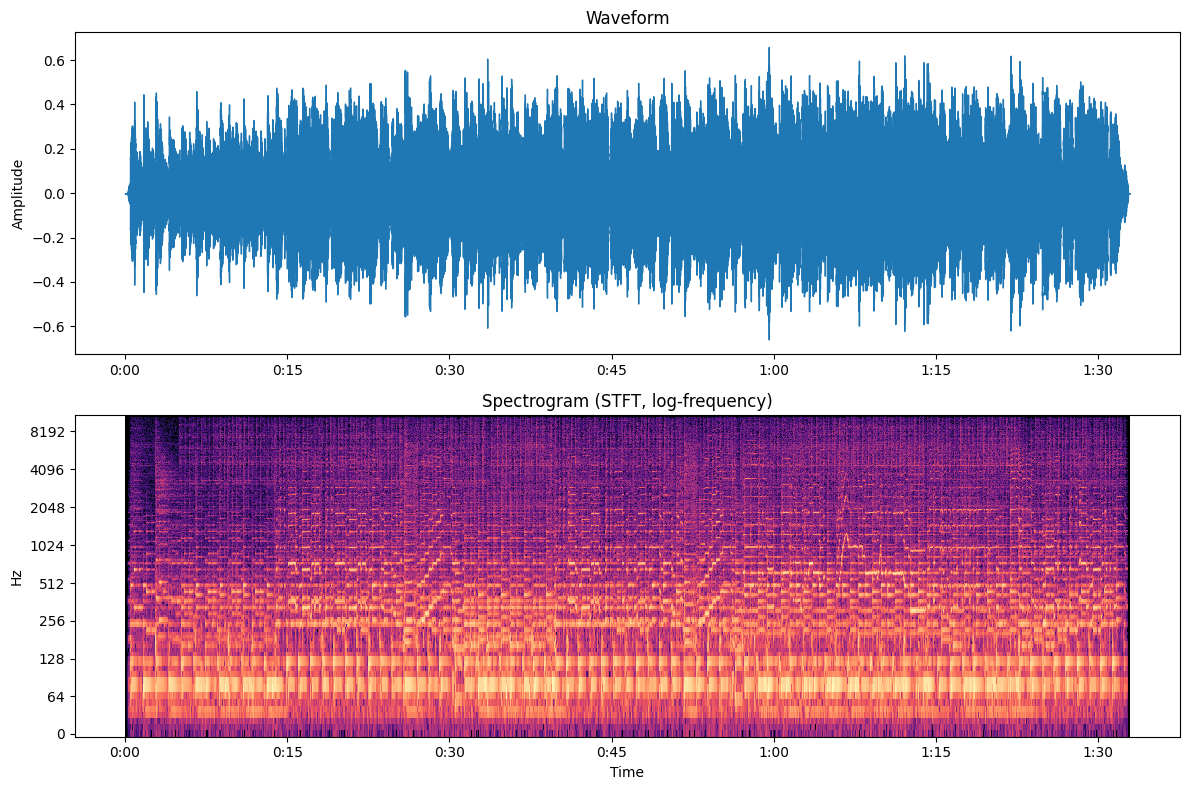

In [14]:
import librosa
from IPython.display import Audio, display
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

audio_path = "audio/week5_audio_ex_2_coltrane_myfavthings.mp3"

# Waveform and spectrogram (uses y, sr, hop_length already defined in the notebook)
plt.figure(figsize=(12, 8))

# Waveform
ax1 = plt.subplot(2, 1, 1)
try:
    librosa.display.waveshow(y, sr=sr)
except AttributeError:
    librosa.display.waveplot(y, sr=sr)
plt.title('Waveform')
plt.xlabel('')
plt.ylabel('Amplitude')

# Spectrogram (STFT -> dB)
ax2 = plt.subplot(2, 1, 2)
S = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop_length))
S_db = librosa.amplitude_to_db(S, ref=np.max)
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='log', cmap='magma')
plt.title('Spectrogram (STFT, log-frequency)')

# Align x-axes
ax2.set_xlim(ax1.get_xlim())
plt.tight_layout()
plt.show()

# show a playbar for the loaded audio below the spectrogram
display(Audio(y, rate=sr))


### Feature extraction

Feature extraction converts waveforms into compact descriptors that better reflect hearing and musical structure. Common choices include spectral measures (centroid, bandwidth), timbral representations (MFCCs), harmonic summaries (chroma, F0 contours), and temporal cues (onset strength, tempo). Parameter choices—window length, hop size, mel bands, and normalization—determine temporal/spectral resolution and strongly affect model performance.

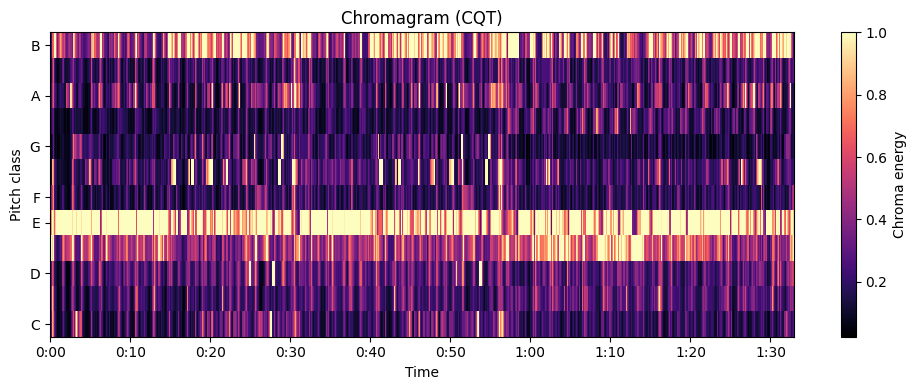

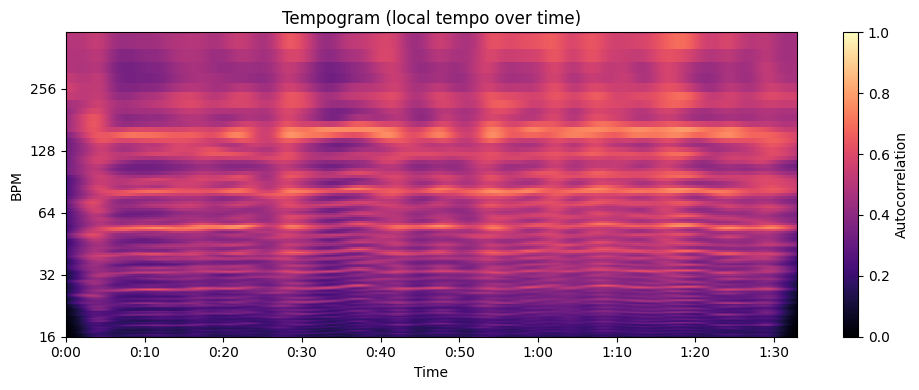

In [15]:
y, sr = librosa.load(audio_path, sr=22050, mono=True)
hop_length = 512

# Compute chromagram (CQT-based)
chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop_length)

plt.figure(figsize=(10, 4))
librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', sr=sr, hop_length=hop_length, cmap='magma')
plt.colorbar(label='Chroma energy')
plt.title('Chromagram (CQT)')
plt.tight_layout()
# show the plot and an audio playbar for the loaded file
plt.show()

# Tempogram (rhythmic autocorrelation)
onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
tempogram = librosa.feature.tempogram(onset_envelope=onset_env, sr=sr, hop_length=hop_length)

plt.figure(figsize=(10, 4))
librosa.display.specshow(tempogram, sr=sr, hop_length=hop_length, x_axis='time', y_axis='tempo', cmap='magma')
plt.colorbar(label='Autocorrelation')
plt.title('Tempogram (local tempo over time)')
plt.tight_layout()
plt.show()

In [ ]:
# Estimate tempo and pitch (overwrites onset_env with a fresh estimate)
# Uses existing variables: y, sr, hop_length, fmin, fmax

# recompute onset strength (safe if previous onset_env is empty)
onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)

# global tempo (BPM) and beat tracking
tempo_bpm = float(librosa.beat.tempo(onset_envelope=onset_env, sr=sr, hop_length=hop_length)[0])
tempo_bt, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr, hop_length=hop_length)

print(f"Estimated tempo (librosa.beat.tempo): {tempo_bpm:.1f} BPM")
print(f"Estimated tempo (beat_track): {tempo_bt:.1f} BPM, detected {len(beats)} beats")

# pitch estimation with YIN (frame-wise fundamental frequency, NaN for unvoiced frames)
f0_yin = librosa.yin(y, fmin=fmin, fmax=fmax, sr=sr, hop_length=hop_length)
times = librosa.times_like(f0_yin, sr=sr, hop_length=hop_length)

# summary stats
voiced_mask = ~np.isnan(f0_yin)
voiced_ratio = voiced_mask.mean()
if np.any(voiced_mask):
    median_f0 = float(np.nanmedian(f0_yin))
    midi_median = float(librosa.hz_to_midi(median_f0))
    print(f"Median voiced f0: {median_f0:.1f} Hz (≈ MIDI {midi_median:.1f}), voiced frames: {voiced_ratio:.2%}")
else:
    median_f0 = np.nan
    print("No voiced frames detected with YIN in the given fmin/fmax range.")

# quick visualization of the pitch contour
plt.figure(figsize=(10, 3))
plt.plot(times, f0_yin, '.', markersize=2, alpha=0.6, label='f0 (YIN)')
if not np.isnan(median_f0):
    plt.hlines(median_f0, times[0], times[-1], color='C1', linewidth=1.2, label=f'median f0 {median_f0:.1f} Hz')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Estimated pitch contour (YIN)')
plt.ylim(max(0.9 * fmin, 20), 1.1 * fmax)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()



### Segmentation and event detection

Segmentation and event detection locate boundaries and discrete events such as onsets, beats, section changes, or speech activity. Methods span signal‑processing heuristics (peak‑picking on onset strength), change‑point detection, and learned detectors. Good segmentation enables indexing, alignment, and targeted processing and is typically evaluated with event‑level metrics and tolerance windows.

### Classification and recognition

Classification maps features or learned representations to labels—instrument, genre, speech/music, or emotion—using models from SVMs and random forests to CNNs and transformers. Practical issues include label quality, class imbalance, interpretability, and metric selection (accuracy vs precision/recall, per‑class evaluation). Begin with simple baselines and increase model complexity only as justified by validation.

### Temporal modeling
Temporal modeling captures sequence and context — rhythm, melody, phrasing, and long‑range dependencies — enabling systems to reason about how musical or speech events evolve over time. Common modeling families and their characteristics:

- [Hidden Markov Models (HMMs)](https://en.wikipedia.org/wiki/Hidden_Markov_model) are probabilistic, generative sequence models that represent latent states and state transitions; they are useful for producing interpretable event or state sequences (for example, note or phoneme sequences) and work well in low-data regimes. Their strengths are being lightweight, well‑understood, and providing explicit temporal‑state structure, while their limitations include limited capacity for long‑range dependencies and difficulty modeling complex, high‑dimensional observations.

- [Recurrent Neural Networks (RNNs)](https://en.wikipedia.org/wiki/Recurrent_neural_network) and [Long Short‑Term Memory (LSTM)](https://en.wikipedia.org/wiki/Long_short-term_memory) networks process sequences step‑by‑step, with LSTMs using gating mechanisms to mitigate vanishing/exploding gradients and capture longer dependencies; they are widely used for frame‑level labeling, sequence‑to‑sequence tasks, and modeling expressive timing. Their advantages include good modeling of moderate temporal context and dynamics, whereas sequential computation can limit throughput and increase latency compared with more parallelizable architectures.

- Temporal or dilated convolutional networks (temporal CNNs, [TCNs](https://en.wikipedia.org/wiki/Temporal_convolutional_network)) use causal, time‑respecting convolutions often combined with [dilated convolutions](https://en.wikipedia.org/wiki/Dilated_convolution) to model long histories in parallel; they offer large receptive fields with efficient, parallelizable computation and can be designed for low‑latency streaming. Pros include parallel inference and controllable receptive field size; cons include sensitivity to architectural choices (dilation rates, kernel sizes) which determine required context and memory usage. See also [convolutional neural network](https://en.wikipedia.org/wiki/Convolutional_neural_network).

- [Transformers](https://en.wikipedia.org/wiki/Transformer_(machine_learning_model)) and [attention‑based models](https://en.wikipedia.org/wiki/Attention_(machine_learning)) use self‑attention to model arbitrary pairwise interactions across a sequence, excelling at very long‑range dependencies and sequence‑to‑sequence tasks such as transcription or structural analysis when paired with spectrogram or learned front‑ends. They often achieve state‑of‑the‑art results and provide flexible context modeling, but incur high compute and memory costs (quadratic attention can be expensive for long audio), though sparse/efficient attention variants can mitigate this.



Key trade‑offs and deployment considerations:
- Latency vs accuracy: models with large receptive fields or global attention typically improve offline accuracy but increase buffering and latency. For realtime use, prefer causal architectures (causal convolutions, streaming RNNs) and small lookahead. See: https://en.wikipedia.org/wiki/Real-time_computing
- Model size and compute: bigger models often give better performance but require more memory/compute and increase inference time — important for embedded or realtime systems. Consider model compression/pruning or efficient architectures. See: https://en.wikipedia.org/wiki/Model_compression
- Data requirements and generalization: deep sequence models need substantial, diverse labeled data to avoid overfitting; augmentation and self‑supervised pretraining help when labels are scarce. See: https://en.wikipedia.org/wiki/Overfitting and https://en.wikipedia.org/wiki/Self-supervised_learning
- Streaming & buffering: design buffering and frame‑rates to meet latency goals while preserving enough context for accurate predictions (tradeoff between hop/window size and responsiveness).




### Higher‑level analysis and outputs

Higher‑level analysis transforms low‑level signals into actionable results: structural annotations, harmonic or mood estimates, symbolic exports (MIDI, MusicXML), visualizations, or interactive feedback. Design outputs for intended users (students, performers, researchers), consider latency and provenance, ensure interoperability, and validate results with human‑grounded evaluation so outputs meaningfully reflect perception and musical practice.

```{admonition} Python
:class: note
[Python](https://www.python.org/) is a high-level programming language widely used for scientific computing, data analysis, and machine learning. It is based on loading various libraries that extend functionality, including general scientific computing libraries ([NumPy](https://numpy.org/), [SciPy](https://scipy.org/), [pandas](https://pandas.pydata.org/)), specific audio libraries ([librosa](https://librosa.org/), [Essentia](https://essentia.upf.edu/), [madmom](https://github.com/CPJKU/madmom)), and machine learning libraries ([PyTorch](https://pytorch.org/), [TensorFlow](https://www.tensorflow.org/)). Its clean syntax makes it relatively quick to learn and it can be deployed on many systems.
```

```{admonition} Jupyter Notebook
:class: note
[Jupyter Notebook](https://jupyter.org/) is an interactive, web-based environment for creating and sharing documents that combine live code, rich text, visualizations, and results. Code is organized into executable cells with outputs shown inline, enabling iterative experimentation, data exploration, and reproducible workflows. Notebooks support multiple kernels (Python, R, Julia), rich media, and easy export to formats like HTML and PDF.
```


### Resources

Today, most machine listening tasks are done in Python. Here are three of the most popular libraries in use: 

- [librosa](https://librosa.org/): general-purpose, high-level Python library for audio / music analysis (easy prototyping, ML features).
- [Essentia](https://essentia.upf.edu/): C++ DSP library with Python bindings (very large feature set, performance-oriented, production-ready).
- [madmom](https://github.com/CPJKU/madmom): Python/Cython library focused on MIR tasks (beats, onsets, tempo, with pretrained NN models and pipelines).


## Music Information Retrieval

[Music Information Retrieval](https://en.wikipedia.org/wiki/Music_information_retrieval) (MIR) can be seen as a specialized form of machine listening, aimed at extracting structured, actionable information from musical audio and related data. MIR combines signal processing, machine learning, music theory, and human-centred evaluation to support tasks such as metadata extraction, music search, analysis, learning, and interactive applications. The following sections describe core MIR tasks, typical approaches, and practical considerations for building and evaluating systems.

### Overview
MIR tasks operate at different levels of abstraction: low-level signal descriptors (spectral, temporal, harmonic), mid-level events (onsets, beats, notes), and high-level semantics (genre, mood, structure). Effective MIR pipelines often combine careful preprocessing, feature extraction, event detection, and modeling (classical or learned), with task-specific evaluation and human validation.

### Classification
Classification maps extracted features or learned representations to categorical labels such as genre, instrument, or mood. Approaches range from classical machine learning (e.g., [support vector machines](https://en.wikipedia.org/wiki/Support-vector_machine), [random forests](https://en.wikipedia.org/wiki/Random_forest)) on hand-crafted features ([MFCCs](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum), [chroma](https://en.wikipedia.org/wiki/Chroma_feature)) to deep models ([CNNs](https://en.wikipedia.org/wiki/Convolutional_neural_network), [transformers](https://en.wikipedia.org/wiki/Transformer_(machine_learning_model))) trained end-to-end on [spectrograms](https://en.wikipedia.org/wiki/Spectrogram) or learned representations ([representation learning](https://en.wikipedia.org/wiki/Representation_learning)). Key issues include [class imbalance](https://en.wikipedia.org/wiki/Imbalanced_dataset), [domain mismatch / domain adaptation](https://en.wikipedia.org/wiki/Domain_adaptation) between datasets and deployment audio, and the choice of metrics (per-class [precision & recall](https://en.wikipedia.org/wiki/Precision_and_recall), macro vs. micro averaging). Start with simple baselines and use calibration ([calibration (statistics)](https://en.wikipedia.org/wiki/Calibration_(statistics))), interpretability tools ([interpretability](https://en.wikipedia.org/wiki/Interpretability)), and uncertainty estimation ([uncertainty quantification](https://en.wikipedia.org/wiki/Uncertainty_quantification)) for production systems.

### Recommendation
Recommendation systems use MIR outputs and user interaction data to suggest relevant music. Content-based methods leverage extracted audio features and metadata; collaborative filtering uses user-item interactions; hybrid approaches combine both. Practical considerations include cold-start for new tracks/users, fairness and diversity in recommendations, privacy of user data, and scalable retrieval/indexing for large music catalogs.

### Source Separation
Source separation isolates individual instruments or voices from a mixed audio signal. Methods include traditional matrix factorization and spatial filtering, as well as modern deep-learning approaches (U‑Nets, Conv‑TasNet, time-domain separation). Evaluation commonly uses signal‑level metrics (SDR, SIR, SAR) and perceptual listening tests. Separation quality depends strongly on training data diversity, labeling fidelity, and mixture complexity; post-processing and masking heuristics can improve perceptual results.

![Source separation](https://upload.wikimedia.org/wikipedia/commons/c/c3/Polyphonic_note_separation_%26_manipulation.jpg)

*An example of polyphonic note separation ([Wikipedia](https://en.wikipedia.org/wiki/Signal_separation#/media/File:Polyphonic_note_separation_&_manipulation.jpg)).*

### Transcription
Automatic transcription converts audio into symbolic representations such as MIDI or MusicXML. Tasks range from monophonic pitch tracking to polyphonic multi-instrument transcription. Techniques include spectral analysis and onset/pitch detection heuristics, probabilistic sequence models, and end-to-end deep architectures with sequence losses (CTC, seq2seq). Challenges include polyphony, expressive timing, tuning deviations, and evaluating alignment accuracy versus symbolic correctness.

### Question‑Answering and Semantic Retrieval
Audio-based question‑answering and semantic retrieval combine MIR with natural language interfaces: queries like “which song has a trumpet solo?” or “find tracks with a fast tempo and major mode.” Systems integrate audio tagging, metadata, lyrics, and semantic embeddings to match queries to audio segments. Robustness depends on accurate multimodal indexing, interpretable tag sets, and careful mapping between user language and model labels.

### Segmentation and Structure Analysis
Segmentation partitions tracks into meaningful regions (intro, verse, chorus) or detects events (sections, transitions). Approaches use novelty detection on self-similarity matrices, supervised boundary detectors, or learned representations for structural segmentation. Applications include navigation, summarization, and alignment. Evaluation typically uses boundary precision/recall with tolerance windows and structural similarity measures.

### Feature Extraction
Feature extraction produces compact descriptors that capture perceptual or musical properties: spectral features (centroid, bandwidth), timbral features (MFCCs), harmonic descriptors (chroma, pitch contours), and temporal features (onset strength, tempo). Choose parameters (window length, hop size, mel bands) to match the temporal and spectral resolution required by the task. Normalization, augmentation, and invariant representations (e.g., pitch- or tempo-invariant features) improve robustness.

### Evaluation, Datasets, and Benchmarks
Use standardized datasets and metrics appropriate to each task (e.g., GTZAN for genre with caveats, MusicNet for transcription, DSD100 for separation). Combine objective metrics with perceptual evaluations when possible. Always check dataset licensing and biases, and report per-class and aggregate metrics to reveal failure modes.

### Practical Considerations
- Latency and deployment constraints: decide realtime vs offline trade-offs early.  
- Data quality: ensure annotations are consistent and representative.  
- Augmentation and robustness: apply pitch‑shift, time‑stretch, and noise to reduce overfitting.  
- Ethics & licensing: respect copyright, user privacy, and address demographic or cultural biases in training data.

Together these components form a practical MIR workflow: define the task and metrics, collect and preprocess data, select appropriate features and models, evaluate with relevant benchmarks and human studies, and iterate towards robust, explainable systems.

### Data

Machine listening relies on various types of data:

- **Symbolic Data**: Representations like [MIDI](https://en.wikipedia.org/wiki/MIDI) and [MusicXML](https://en.wikipedia.org/wiki/MusicXML).
- **Subsymbolic Data**: Includes raw audio, video, and sensor data.
- **Metadata**: Information about the audio, such as artist or album details. Learn about [metadata](https://en.wikipedia.org/wiki/Metadata).
- **Paradata**: Data about the process of data collection or analysis.
- **User Data**: Information about user interactions and preferences.

## Artificial Intelligence (AI)

### Rule-based systems
Rule-based systems use deterministic signal-processing heuristics—thresholds, peak-picking and spectral rules—to make decisions. They are lightweight and interpretable, well suited to low-latency tasks such as onset picking or simple voice activity detection, but can be brittle in noisy or out-of-domain conditions.

### Learning-based systems
Learning-based approaches range from classical supervised models (SVMs, random forests) operating on hand-crafted features (MFCCs, chroma) to deep architectures (CNNs for timbre/scene classification, RNNs/LSTMs for temporal modelling, transformers for long-range context) trained end-to-end on spectrograms or learned embeddings. Self‑ and semi‑supervised methods perform contrastive or predictive pretraining on large unlabeled audio corpora and are fine-tuned for downstream tasks, which is useful when labeled data are scarce. Examples include CNN instrument classifiers, U‑Net/Conv‑TasNet for source separation, and seq2seq/CTC models for transcription.

### Hybrid approaches
Hybrid approaches combine signal-processing priors with learned components—for example, learned spectrogram post‑filters, or rule-based event grouping applied to ML-detected onsets—to balance interpretability, performance, and data requirements.

### Practical considerations
Key practical issues are annotation quality and class balance, synthetic augmentation (time-stretch, pitch-shift, noise), and domain mismatch between training and deployment. Choose evaluation metrics that match the task (precision/recall/F1, SDR/SIR, frame/segment accuracy). Deployment constraints—model size, latency, hardware limits, and update strategy—shape architecture choices, while robustness and ethics require attention to bias, adversarial/noisy inputs, and licensing/privacy compliance.

### Tools & libraries
Common toolchains pair feature/DSP libraries (librosa, madmom, Essentia) with modeling frameworks and infrastructure (PyTorch, TensorFlow, torchaudio, Hugging Face) and task-specific packages (Asteroid, nnAudio, pretrained audio transformers).

### Typical workflow
A typical workflow: define the task and metrics; collect, annotate and augment data; pick a baseline (rule-based or simple ML) and iterate toward deeper models; validate on held-out data; optimize for latency and robustness; deploy and monitor the system.

### Time

Machine listening systems can operate in different time modes:

- **Realtime**: Systems that process audio as it is received, such as [online systems](https://en.wikipedia.org/wiki/Real-time_computing).
- **Non-Realtime**: Systems that process audio after it has been recorded, such as [offline systems](https://en.wikipedia.org/wiki/Batch_processing).



## Questions

1. What is the difference between a tone and a note?
2. How does a spectrogram differ from a waveform in audio visualization?
3. What is the purpose of the constant-Q transform and why is it perceptually relevant?
4. Why is timbre important for our perception of melody and harmony? 
5. What are the main differences between symbolic representations such as MIDI, ABC Notation, and MusicXML?